# LightGBM vs XGBoost: Predicting Diabetes

**Objective:** Compare the performance of two gradient-boosting algorithms, **LightGBM** and **XGBoost**, on the Pima Indians diabetes dataset (`diabetes.csv`).

**Workflow**
1. Exploratory Data Analysis (EDA)
2. Data preprocessing
3. Building predictive models (baseline, cross-validation, hyperparameter tuning)
4. Comparative analysis
5. Summary report

> **Note on the assignment brief:** the brief's EDA section mentions the *Titanic* dataset and "survival", but its objective names the *diabetes* dataset, and the supplied file is `diabetes.csv`. I therefore apply every EDA step to the diabetes data, with **`Outcome`** (1 = diabetic, 0 = non-diabetic) as the target in place of "survival".

## 0. Setup

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, classification_report)
from scipy.stats import loguniform, randint, uniform

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")      # keep the notebook output clean
RANDOM_STATE = 42                      # one seed everywhere -> reproducible results
np.random.seed(RANDOM_STATE)

# Plot styling and a fixed colour per model/class so colours mean the same thing in every chart
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
COLORS = {"LightGBM": "#2a9d8f", "XGBoost": "#e76f51"}
CLASS_COLORS = {0: "#457b9d", 1: "#e63946"}

## 1. Exploratory Data Analysis (EDA)

### 1.1 Load the dataset

In [2]:
df = pd.read_csv("diabetes.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 768 rows x 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


The dataset has 768 patients, 8 numeric predictors and a binary target `Outcome`.

| Feature | Meaning |
|---|---|
| Pregnancies | Number of pregnancies |
| Glucose | Plasma glucose concentration (2 h oral glucose tolerance test) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin-fold thickness (mm) |
| Insulin | 2-hour serum insulin (mu U/ml) |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Diabetes heredity score |
| Age | Age in years |
| Outcome | **Target**: 1 = diabetes, 0 = no diabetes |

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


### 1.2 Check for missing values

`isnull()` is the standard check. In this dataset, though, missing values are often stored as **0**, which is physiologically impossible for glucose, blood pressure, skin thickness, insulin and BMI. I check both.

In [5]:
# 1) Explicit missing values (NaN)
print("Explicit NaN values per column:")
print(df.isnull().sum().to_string())

# 2) Hidden missing values: zeros in columns where 0 is not a valid measurement
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
hidden = pd.DataFrame({
    "zero_count": (df[zero_as_missing] == 0).sum(),
    "zero_pct": ((df[zero_as_missing] == 0).mean() * 100).round(1),
})
hidden

Explicit NaN values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0


,zero_count,zero_pct
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


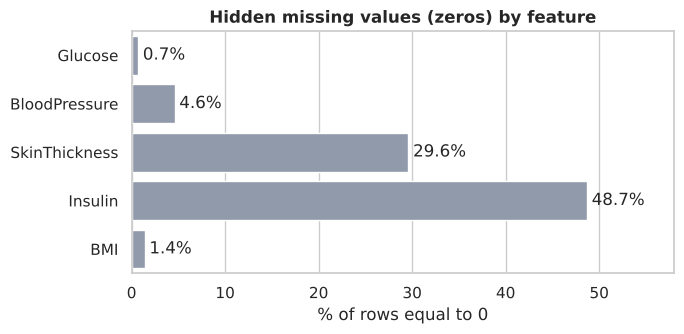

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(x=hidden.zero_pct, y=hidden.index, color="#8d99ae", ax=ax)
for i, v in enumerate(hidden.zero_pct):
    ax.text(v + 0.5, i, f"{v}%", va="center")
ax.set(title="Hidden missing values (zeros) by feature", xlabel="% of rows equal to 0", ylabel="", xlim=(0, 58))
plt.tight_layout(); plt.show()

There are no explicit `NaN`s, but **Insulin (~49%) and SkinThickness (~30%)** contain many hidden missing values, plus a few in Glucose, BloodPressure and BMI. I convert these zeros to `NaN` so they are not mistaken for real measurements. The *imputation* itself happens later, **after** the train/test split, so test data cannot leak into the imputation statistics.

`Pregnancies = 0` is a legitimate value and is left unchanged.

In [7]:
df_clean = df.copy()
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)
print("Missing values after marking invalid zeros as NaN:")
print(df_clean.isnull().sum().to_string())

Missing values after marking invalid zeros as NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0


### 1.3 Distributions: histograms and box plots

First the target balance, then each feature's distribution (missing values excluded).

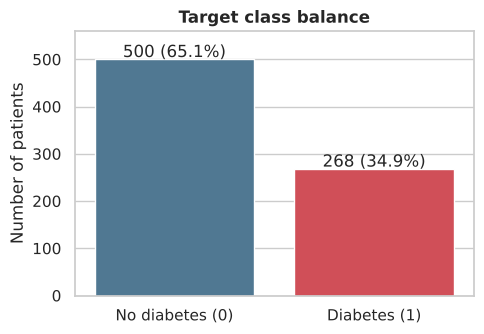

In [8]:
counts = df_clean["Outcome"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=["No diabetes (0)", "Diabetes (1)"], y=counts.values, palette=[CLASS_COLORS[0], CLASS_COLORS[1]], ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, f"{v} ({v / len(df_clean):.1%})", ha="center")
ax.set(title="Target class balance", ylabel="Number of patients", xlabel="", ylim=(0, 560))
plt.tight_layout(); plt.show()

The classes are moderately imbalanced (about 65% / 35%). Accuracy alone would therefore be misleading, so I also track **precision, recall, F1 and ROC-AUC**.

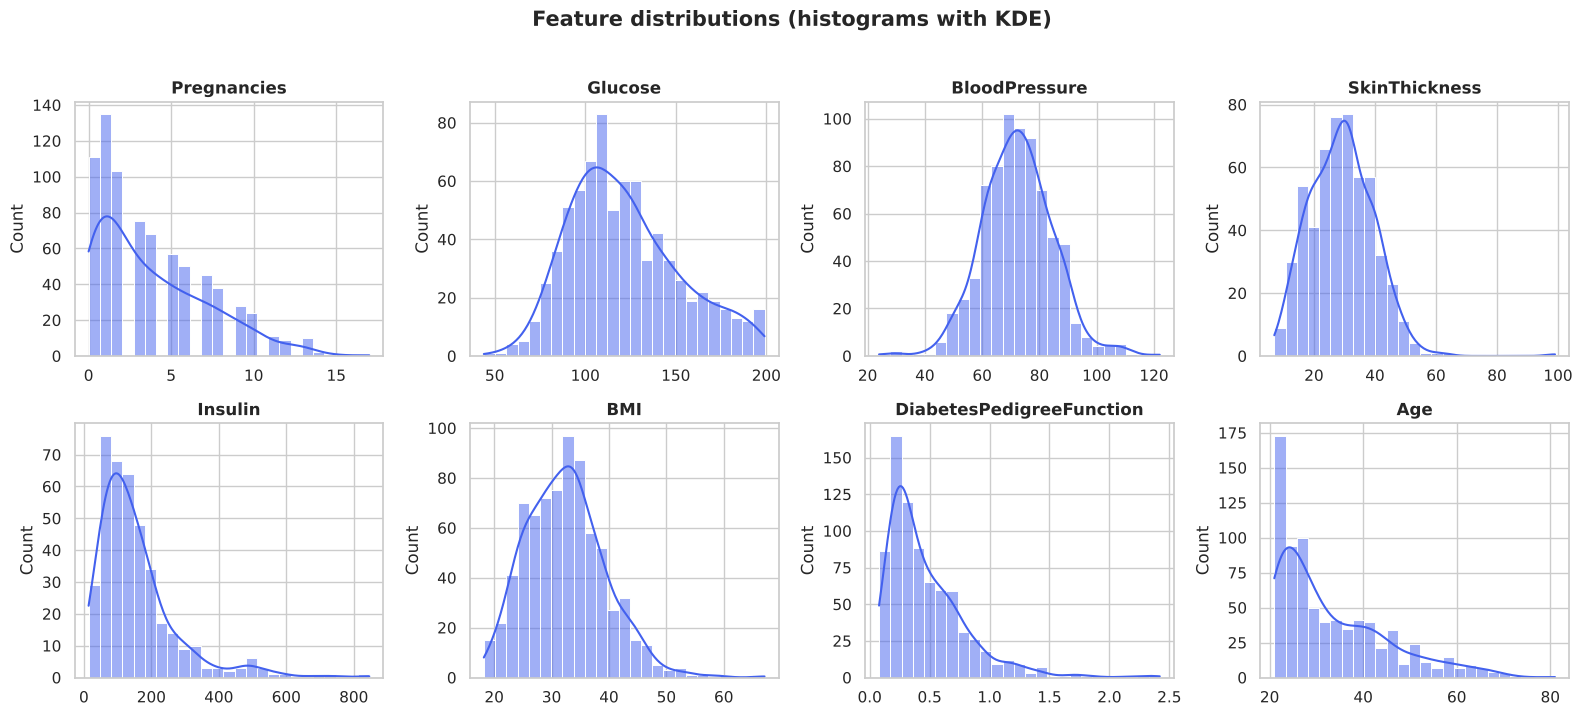

In [9]:
features = [c for c in df_clean.columns if c != "Outcome"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(df_clean[col].dropna(), bins=25, kde=True, color="#4361ee", ax=ax)
    ax.set(title=col, xlabel="", ylabel="Count")
fig.suptitle("Feature distributions (histograms with KDE)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

Glucose, BloodPressure and BMI are roughly bell-shaped. **Insulin, DiabetesPedigreeFunction, Age and Pregnancies are right-skewed.** Skew is not a problem for tree-based models, which depend only on the ordering of values.

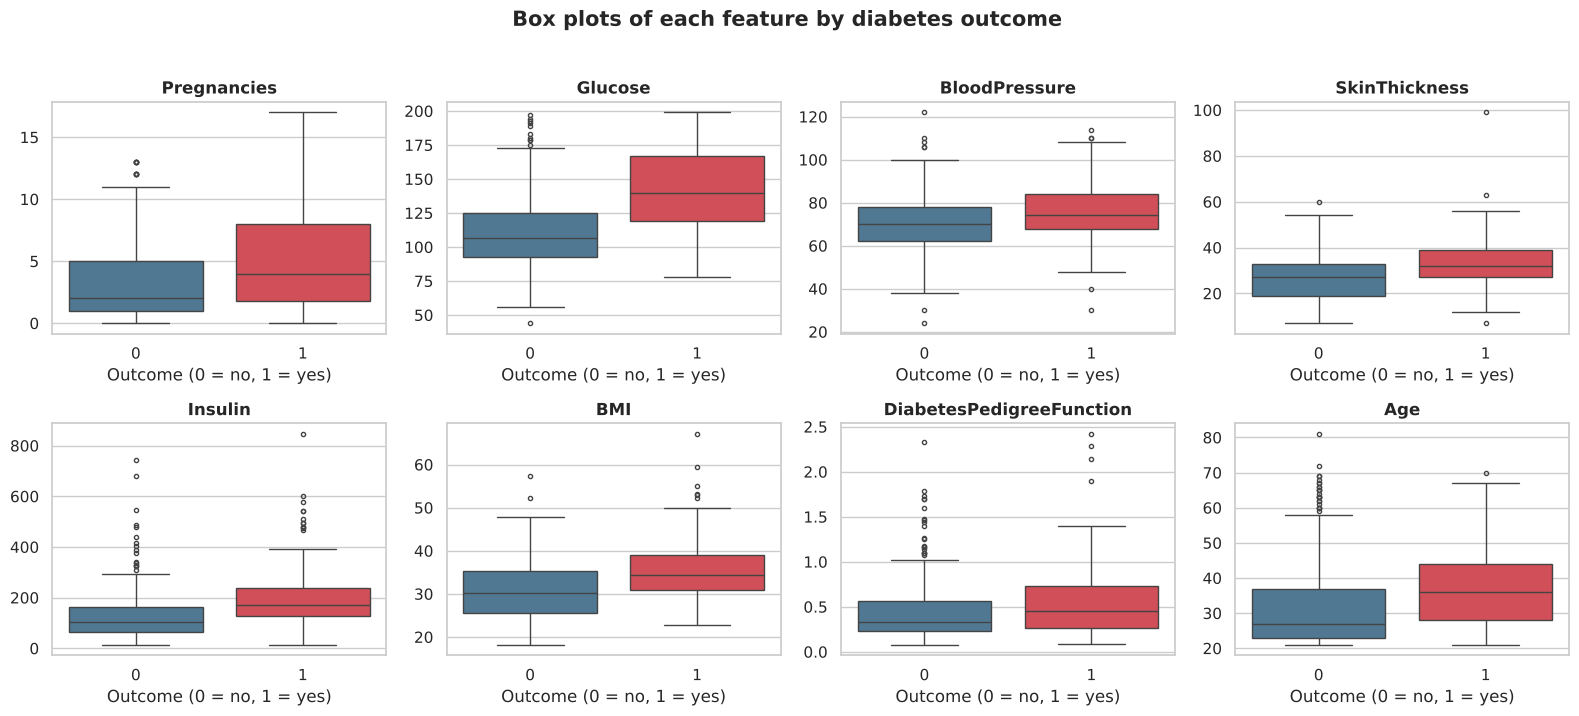

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(data=df_clean, x="Outcome", y=col, palette=[CLASS_COLORS[0], CLASS_COLORS[1]], ax=ax, fliersize=3)
    ax.set(title=col, xlabel="Outcome (0 = no, 1 = yes)", ylabel="")
fig.suptitle("Box plots of each feature by diabetes outcome", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

Observations:
- **Glucose** separates the classes best: diabetic patients have a clearly higher median.
- **BMI, Age and Insulin** are also higher for the diabetic group.
- Several features (Insulin, DiabetesPedigreeFunction, SkinThickness) have extreme outliers. They look like genuine measurements rather than errors, and gradient-boosted trees are robust to them, so I **keep them**.

### 1.4 Relationships between features and the outcome

Scatter plots show how pairs of features jointly relate to diabetes. Bar plots show the diabetes rate across feature groups, the diabetes analogue of "survival rate by group".

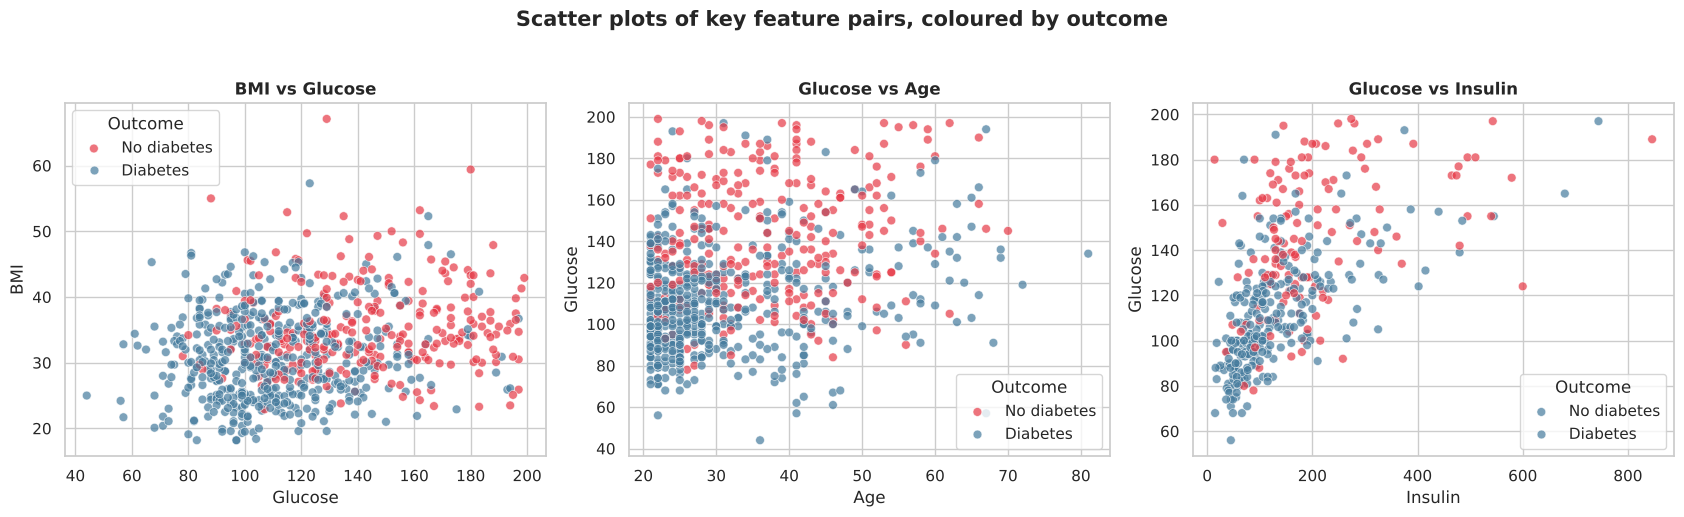

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pairs = [("Glucose", "BMI"), ("Age", "Glucose"), ("Insulin", "Glucose")]
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=df_clean, x=x, y=y, hue="Outcome", palette=CLASS_COLORS, alpha=0.7, s=40, ax=ax)
    ax.set_title(f"{y} vs {x}")
    ax.legend(title="Outcome", labels=["No diabetes", "Diabetes"])
fig.suptitle("Scatter plots of key feature pairs, coloured by outcome", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

Diabetic patients (red) concentrate in the **high-Glucose** region, especially when combined with higher BMI or Age. Glucose alone does not separate the classes perfectly, which is why a multi-feature model is needed.

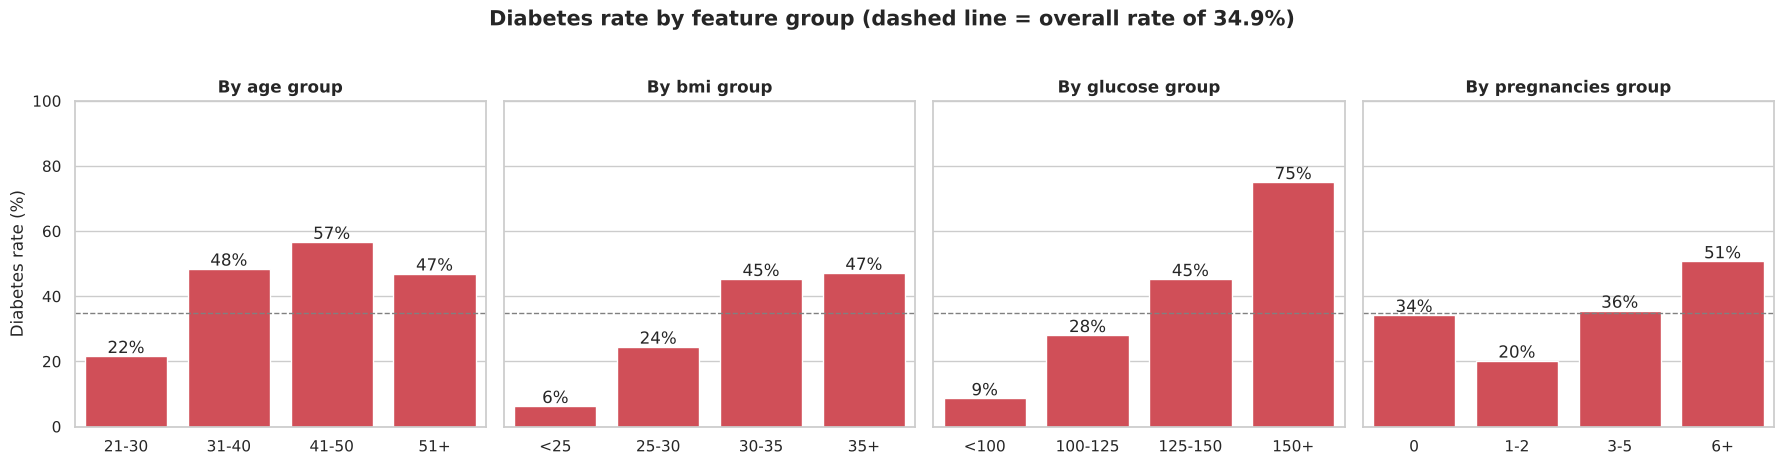

In [12]:
# Bin a few features into groups to compute the diabetes rate per group
tmp = df_clean.copy()
tmp["Age group"] = pd.cut(tmp["Age"], [20, 30, 40, 50, 100], labels=["21-30", "31-40", "41-50", "51+"])
tmp["BMI group"] = pd.cut(tmp["BMI"], [0, 25, 30, 35, 100], labels=["<25", "25-30", "30-35", "35+"])
tmp["Glucose group"] = pd.cut(tmp["Glucose"], [0, 100, 125, 150, 250], labels=["<100", "100-125", "125-150", "150+"])
tmp["Pregnancies group"] = pd.cut(tmp["Pregnancies"], [-1, 0, 2, 5, 20], labels=["0", "1-2", "3-5", "6+"])

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, g in zip(axes, ["Age group", "BMI group", "Glucose group", "Pregnancies group"]):
    rate = tmp.groupby(g, observed=True)["Outcome"].mean() * 100
    sns.barplot(x=rate.index.astype(str), y=rate.values, color="#e63946", ax=ax)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 1, f"{v:.0f}%", ha="center")
    ax.axhline(df_clean["Outcome"].mean() * 100, color="grey", ls="--", lw=1)
    ax.set(title=f"By {g.lower()}", xlabel="", ylabel="Diabetes rate (%)", ylim=(0, 100))
fig.suptitle("Diabetes rate by feature group (dashed line = overall rate of 34.9%)", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

The diabetes rate **rises steeply with Glucose** (from a small minority below 100 to a large majority above 150) and also with BMI, Age and number of pregnancies.

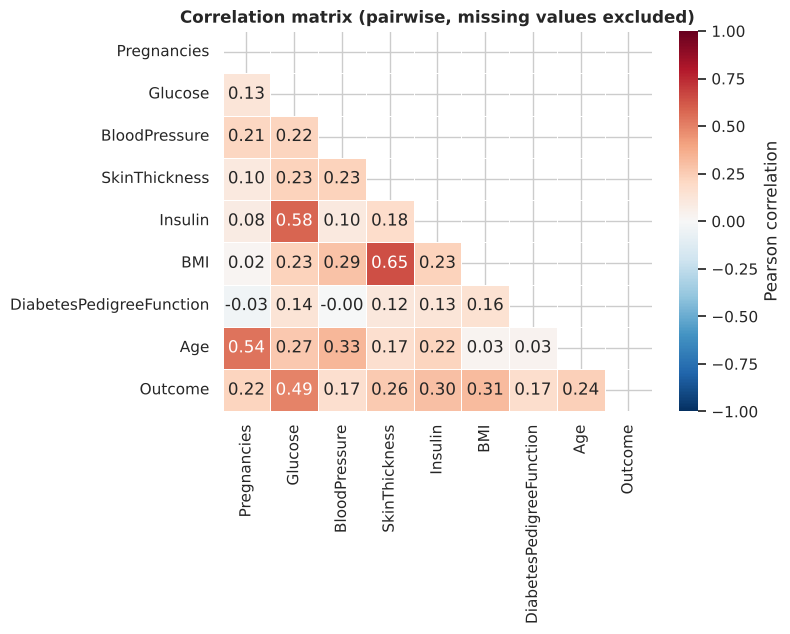

Correlation of each feature with Outcome:
Glucose                     0.495
BMI                         0.314
Insulin                     0.303
SkinThickness               0.259
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.171


In [13]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation matrix (pairwise, missing values excluded)")
plt.tight_layout(); plt.show()

print("Correlation of each feature with Outcome:")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False).round(3).to_string())

**Glucose** (r ≈ 0.50) is the strongest single predictor, followed by BMI and Insulin (≈ 0.3 each), then SkinThickness, Age and Pregnancies. Predictors are only moderately correlated with each other (the highest pair is BMI and SkinThickness, ≈ 0.65), so multicollinearity is not a serious concern, and tree models cope with it anyway.

## 2. Data Preprocessing

### 2.1 Missing values: median imputation

The strategy is **median imputation**. The median is robust to the skew and outliers seen above. To avoid data leakage, the imputer is fitted **only on the training set**. It is placed inside a scikit-learn `Pipeline`, so it is re-fitted on the training portion of each cross-validation fold and applied unchanged to unseen data.

### 2.2 Categorical encoding

In [14]:
# Are there any categorical (non-numeric) predictors that need one-hot / label encoding?
cat_cols = df_clean.drop(columns="Outcome").select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns:", cat_cols if cat_cols else "none")
print("Column dtypes:", df_clean.dtypes.unique().tolist())

Categorical columns: none
Column dtypes: [dtype('int64'), dtype('float64')]


All predictors are already numeric, and the target is already coded as 0/1, so **no one-hot or label encoding is required**. (If the data did contain categories, `OneHotEncoder` would be added to the same pipeline.)

### 2.3 Other preprocessing
- **Feature scaling: not applied.** Tree-based boosting models are invariant to monotonic feature transformations.
- **Outliers: kept** (see Section 1.3).
- **Class imbalance (65/35):** moderate, so I keep the original distribution, use a **stratified** split and stratified CV so each fold preserves the class ratio, and judge models on recall, F1 and ROC-AUC as well as accuracy.

### 2.4 Train/test split

A stratified 80/20 split. The test set stays untouched until the final evaluation.

In [15]:
X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Diabetes rate  train: {y_train.mean():.3f} | test: {y_test.mean():.3f}   (stratification preserves the ratio)")

# Show what the imputer will learn: medians computed from the TRAINING data only
imputer_demo = SimpleImputer(strategy="median").fit(X_train)
print("\nTraining-set medians used for imputation:")
print(pd.Series(imputer_demo.statistics_, index=X.columns).round(2).to_string())

Train: (614, 8), Test: (154, 8)
Diabetes rate  train: 0.349 | test: 0.351   (stratification preserves the ratio)

Training-set medians used for imputation:
Pregnancies                   3.00
Glucose                     117.00
BloodPressure                72.00
SkinThickness                29.00
Insulin                     125.00
BMI                          32.40
DiabetesPedigreeFunction      0.38
Age                          29.00


## 3. Building Predictive Models

### 3.1 Evaluation metrics

| Metric | Why it matters here |
|---|---|
| **Accuracy** | Overall share of correct predictions (can flatter models on imbalanced data) |
| **Precision** | Of patients predicted diabetic, how many truly are (cost of false alarms) |
| **Recall** | Of truly diabetic patients, how many we catch (**cost of missed diagnoses, key in screening**) |
| **F1-score** | Harmonic mean of precision and recall |
| **ROC-AUC** | Threshold-independent ranking quality (**used as the tuning objective**) |

In [16]:
SCORING = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipeline(model):
    # Median imputation (fit on training data only) followed by the classifier
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model)])

def evaluate(pipe, X_te, y_te, threshold=0.5):
    # Test-set metrics at a given decision threshold (default 0.5), plus ROC-AUC from predicted probabilities
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {"accuracy": accuracy_score(y_te, pred), "precision": precision_score(y_te, pred),
            "recall": recall_score(y_te, pred), "f1": f1_score(y_te, pred), "roc_auc": roc_auc_score(y_te, proba)}

### 3.2 Baseline models with 5-fold cross-validation

First, both models with (near-)default hyperparameters, so there is a reference point for what tuning adds. Cross-validation runs on the **training set only**.

In [17]:
baseline_models = {
    "LightGBM": make_pipeline(LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1)),
    "XGBoost":  make_pipeline(XGBClassifier(random_state=RANDOM_STATE, n_jobs=1, eval_metric="logloss")),
}

baseline_cv = {}
for name, pipe in baseline_models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    baseline_cv[name] = {m: (res[f"test_{m}"].mean(), res[f"test_{m}"].std()) for m in SCORING}

baseline_cv_table = pd.DataFrame({n: {m: f"{mu:.3f} ± {sd:.3f}" for m, (mu, sd) in d.items()}
                                  for n, d in baseline_cv.items()})
print("Baseline 5-fold CV on the training set (mean ± std across folds)")
baseline_cv_table

Baseline 5-fold CV on the training set (mean ± std across folds)


,LightGBM,XGBoost
accuracy,0.743 ± 0.032,0.738 ± 0.018
precision,0.648 ± 0.056,0.637 ± 0.042
recall,0.580 ± 0.052,0.593 ± 0.048
f1,0.611 ± 0.047,0.612 ± 0.018
roc_auc,0.798 ± 0.032,0.782 ± 0.021


### 3.3 Hyperparameter tuning

I use **`RandomizedSearchCV`** (5-fold stratified CV on the training set, optimising **ROC-AUC**) with the **same budget of 60 sampled configurations** for each algorithm, so the comparison is fair. Random search explores wide ranges much more cheaply than an exhaustive grid.

Small datasets overfit easily, so the search ranges favour **shallow trees, low learning rates, subsampling and regularisation**.

In [18]:
N_ITER = 60   # same search budget for both algorithms

lgbm_space = {
    "model__n_estimators":      randint(100, 600),
    "model__learning_rate":     loguniform(0.01, 0.2),
    "model__num_leaves":        randint(4, 40),
    "model__max_depth":         [-1, 3, 4, 5, 6],
    "model__min_child_samples": randint(5, 40),
    "model__subsample":         uniform(0.6, 0.4),      # row sampling (0.6-1.0)
    "model__colsample_bytree":  uniform(0.6, 0.4),      # feature sampling (0.6-1.0)
    "model__reg_alpha":         loguniform(1e-3, 10),   # L1 regularisation
    "model__reg_lambda":        loguniform(1e-3, 10),   # L2 regularisation
}
xgb_space = {
    "model__n_estimators":      randint(100, 600),
    "model__learning_rate":     loguniform(0.01, 0.2),
    "model__max_depth":         randint(2, 7),
    "model__min_child_weight":  randint(1, 10),
    "model__subsample":         uniform(0.6, 0.4),
    "model__colsample_bytree":  uniform(0.6, 0.4),
    "model__gamma":             uniform(0, 2),          # min loss reduction to split
    "model__reg_alpha":         loguniform(1e-3, 10),
    "model__reg_lambda":        loguniform(1e-3, 10),
}

# subsample_freq=1 is required for LightGBM to actually apply row subsampling
tuning_setup = {
    "LightGBM": (make_pipeline(LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1, subsample_freq=1)), lgbm_space),
    "XGBoost":  (make_pipeline(XGBClassifier(random_state=RANDOM_STATE, n_jobs=1, eval_metric="logloss")), xgb_space),
}

searches, tuning_time = {}, {}
for name, (pipe, space) in tuning_setup.items():
    t0 = time.perf_counter()
    search = RandomizedSearchCV(pipe, space, n_iter=N_ITER, scoring="roc_auc", cv=cv,
                                random_state=RANDOM_STATE, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)
    tuning_time[name] = time.perf_counter() - t0
    searches[name] = search
    print(f"{name:9s} | best CV ROC-AUC = {search.best_score_:.4f} | search time = {tuning_time[name]:.1f}s")
    print("   best params:", {k.replace('model__', ''): (round(v, 4) if isinstance(v, float) else v)
                              for k, v in search.best_params_.items()})

LightGBM  | best CV ROC-AUC = 0.8405 | search time = 7.7s
   best params: {'colsample_bytree': np.float64(0.7981), 'learning_rate': np.float64(0.0111), 'max_depth': -1, 'min_child_samples': 8, 'n_estimators': 101, 'num_leaves': 9, 'reg_alpha': np.float64(0.0068), 'reg_lambda': np.float64(0.1866), 'subsample': np.float64(0.6125)}


XGBoost   | best CV ROC-AUC = 0.8430 | search time = 7.3s
   best params: {'colsample_bytree': np.float64(0.9589), 'gamma': np.float64(1.8008), 'learning_rate': np.float64(0.0666), 'max_depth': 2, 'min_child_weight': 9, 'n_estimators': 198, 'reg_alpha': np.float64(0.633), 'reg_lambda': np.float64(2.4358), 'subsample': np.float64(0.9425)}


**Cross-validated metrics of the tuned models** (the best configuration re-evaluated with all five metrics, still on the training set):

In [19]:
tuned_cv = {}
for name, search in searches.items():
    res = cross_validate(search.best_estimator_, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    tuned_cv[name] = {m: (res[f"test_{m}"].mean(), res[f"test_{m}"].std()) for m in SCORING}

tuned_cv_table = pd.DataFrame({n: {m: f"{mu:.3f} ± {sd:.3f}" for m, (mu, sd) in d.items()}
                               for n, d in tuned_cv.items()})
print("Tuned models: 5-fold CV on the training set (mean ± std)")
tuned_cv_table

Tuned models: 5-fold CV on the training set (mean ± std)


,LightGBM,XGBoost
accuracy,0.764 ± 0.018,0.772 ± 0.016
precision,0.747 ± 0.070,0.714 ± 0.047
recall,0.500 ± 0.047,0.584 ± 0.039
f1,0.595 ± 0.031,0.641 ± 0.023
roc_auc,0.841 ± 0.021,0.843 ± 0.012


> **Caveat:** the best configuration was *selected* using these same CV folds, so its CV scores are slightly optimistic. The untouched **test set** in the next section gives the unbiased estimate.

### 3.4 Final evaluation on the held-out test set

Each pipeline has already been fitted on the full training set (`refit=True` for the tuned models); baselines are fitted here.

In [20]:
final_models = {}
for name, pipe in baseline_models.items():
    final_models[f"{name} (baseline)"] = pipe.fit(X_train, y_train)
for name, search in searches.items():
    final_models[f"{name} (tuned)"] = search.best_estimator_

test_results = pd.DataFrame({k: evaluate(m, X_test, y_test) for k, m in final_models.items()}).T
test_results.round(3)

,accuracy,precision,recall,f1,roc_auc
LightGBM (baseline),0.760,0.667,0.630,0.648,0.817
XGBoost (baseline),0.766,0.696,0.593,0.640,0.806
LightGBM (tuned),0.747,0.703,0.481,0.571,0.827
XGBoost (tuned),0.753,0.674,0.574,0.620,0.820


In [21]:
for name in ["LightGBM (tuned)", "XGBoost (tuned)"]:
    print(f"===== {name} (default 0.5 threshold) =====")
    print(classification_report(y_test, final_models[name].predict(X_test),
                                target_names=["No diabetes", "Diabetes"], digits=3))

===== LightGBM (tuned) (default 0.5 threshold) =====
              precision    recall  f1-score   support

 No diabetes      0.761     0.890     0.820       100
    Diabetes      0.703     0.481     0.571        54

    accuracy                          0.747       154
   macro avg      0.732     0.686     0.696       154
weighted avg      0.740     0.747     0.733       154

===== XGBoost (tuned) (default 0.5 threshold) =====
              precision    recall  f1-score   support

 No diabetes      0.787     0.850     0.817       100
    Diabetes      0.674     0.574     0.620        54

    accuracy                          0.753       154
   macro avg      0.730     0.712     0.719       154
weighted avg      0.747     0.753     0.748       154



### 3.5 Decision-threshold tuning (addressing the recall drop)

The tuned models improved **ROC-AUC** (better ranking of patients by risk), but at the default **0.5 cut-off** they predict "diabetes" less often, so **recall fell**. For a screening problem, missing a diabetic patient is costlier than a false alarm, so the cut-off should be set deliberately.

I pick, for each tuned model, the threshold that maximises **F1 on out-of-fold training predictions** (`cross_val_predict`). The test set plays no part in this choice, so the test evaluation remains unbiased.

LightGBM : chosen threshold = 0.29  (out-of-fold F1 = 0.693)


XGBoost  : chosen threshold = 0.41  (out-of-fold F1 = 0.693)


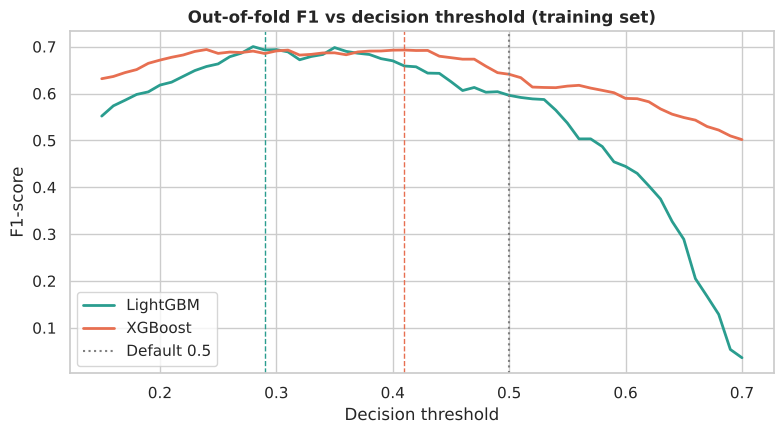

,accuracy,precision,recall,f1,roc_auc
LightGBM (baseline),0.760,0.667,0.630,0.648,0.817
XGBoost (baseline),0.766,0.696,0.593,0.640,0.806
LightGBM (tuned),0.747,0.703,0.481,0.571,0.827
XGBoost (tuned),0.753,0.674,0.574,0.620,0.820
LightGBM (tuned + threshold),0.734,0.582,0.852,0.692,0.827
XGBoost (tuned + threshold),0.747,0.627,0.685,0.655,0.820


In [22]:
grid = np.arange(0.15, 0.71, 0.01)
thresholds, oof_f1 = {}, {}
for algo in ["LightGBM", "XGBoost"]:
    # Out-of-fold probabilities: each training row is predicted by a model that never saw it
    oof = cross_val_predict(searches[algo].best_estimator_, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    oof_f1[algo] = np.array([f1_score(y_train, oof >= t) for t in grid])
    # Smooth the curve slightly (3-point moving average) so the choice is not driven by a single noisy spike
    smooth = np.convolve(oof_f1[algo], np.ones(3) / 3, mode="same")
    thresholds[algo] = float(grid[1:-1][np.argmax(smooth[1:-1])])
    print(f"{algo:9s}: chosen threshold = {thresholds[algo]:.2f}  (out-of-fold F1 = {oof_f1[algo][np.argmin(abs(grid - thresholds[algo]))]:.3f})")

fig, ax = plt.subplots(figsize=(8, 4.5))
for algo in thresholds:
    ax.plot(grid, oof_f1[algo], color=COLORS[algo], lw=2, label=algo)
    ax.axvline(thresholds[algo], color=COLORS[algo], ls="--", lw=1)
ax.axvline(0.5, color="grey", ls=":", label="Default 0.5")
ax.set(title="Out-of-fold F1 vs decision threshold (training set)", xlabel="Decision threshold", ylabel="F1-score")
ax.legend(); plt.tight_layout(); plt.show()

# Add the thresholded models to the test-set results table
for algo in thresholds:
    test_results.loc[f"{algo} (tuned + threshold)"] = evaluate(final_models[f"{algo} (tuned)"], X_test, y_test, thresholds[algo])
test_results.round(3)

## 4. Comparative Analysis

### 4.1 Performance metrics side by side

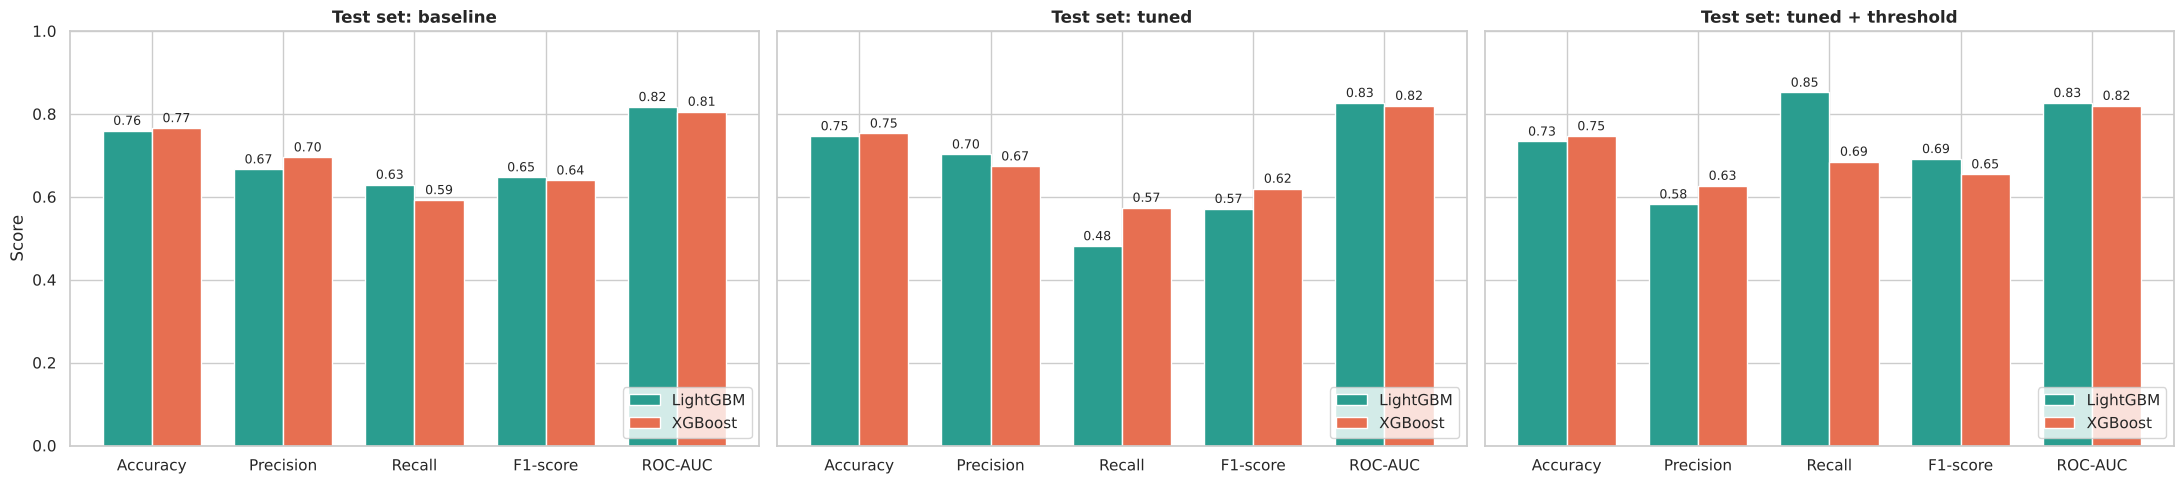

In [23]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
labels = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharey=True)
for ax, stage in zip(axes, ["baseline", "tuned", "tuned + threshold"]):
    plot_df = pd.DataFrame({"LightGBM": test_results.loc[f"LightGBM ({stage})", metrics].values,
                            "XGBoost":  test_results.loc[f"XGBoost ({stage})", metrics].values}, index=labels)
    plot_df.plot.bar(ax=ax, color=[COLORS["LightGBM"], COLORS["XGBoost"]], width=0.75, rot=0, edgecolor="white")
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", padding=2, fontsize=9)
    ax.set(title=f"Test set: {stage}", ylabel="Score", ylim=(0, 1.0))
    ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

In [24]:
# Did tuning help? Change in each test metric versus the baseline
gain = pd.DataFrame({
    (algo, stage): test_results.loc[f"{algo} ({stage})", metrics] - test_results.loc[f"{algo} (baseline)", metrics]
    for algo in ["LightGBM", "XGBoost"] for stage in ["tuned", "tuned + threshold"]}).round(3)
gain.index = labels
print("Change in each test metric relative to the baseline model:")
gain

Change in each test metric relative to the baseline model:


LightGBM                   XGBoost                  
             tuned tuned + threshold   tuned tuned + threshold
Accuracy    -0.013            -0.026  -0.013            -0.019
Precision    0.036            -0.084  -0.022            -0.069
Recall      -0.148             0.222  -0.019             0.093
F1-score    -0.076             0.044  -0.020             0.015
ROC-AUC      0.010             0.010   0.014             0.014

### 4.2 Confusion matrices (tuned + threshold) and ROC curves (tuned models)

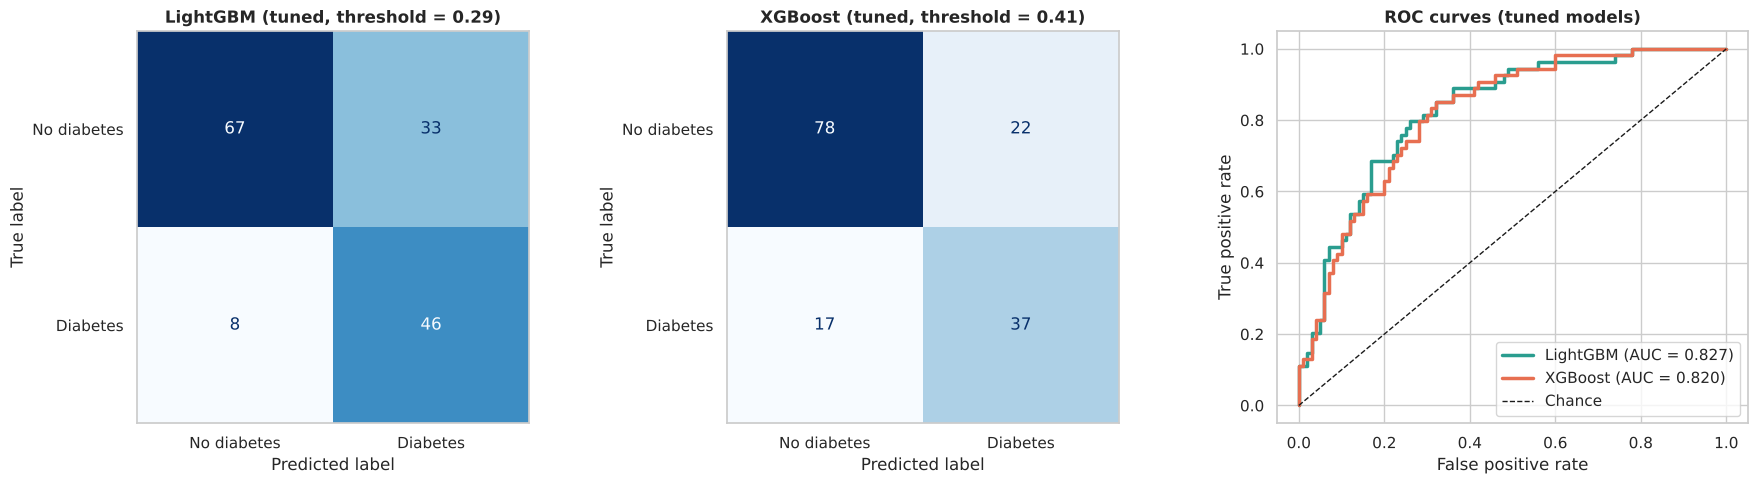

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, algo in zip(axes[:2], ["LightGBM", "XGBoost"]):
    pred = (final_models[f"{algo} (tuned)"].predict_proba(X_test)[:, 1] >= thresholds[algo]).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax,
        display_labels=["No diabetes", "Diabetes"], cmap="Blues", colorbar=False)
    ax.set_title(f"{algo} (tuned, threshold = {thresholds[algo]:.2f})"); ax.grid(False)

for algo in ["LightGBM", "XGBoost"]:
    proba = final_models[f"{algo} (tuned)"].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[2].plot(fpr, tpr, lw=2.5, color=COLORS[algo], label=f"{algo} (AUC = {roc_auc_score(y_test, proba):.3f})")
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
axes[2].set(title="ROC curves (tuned models)", xlabel="False positive rate", ylabel="True positive rate")
axes[2].legend(loc="lower right")
plt.tight_layout(); plt.show()

### 4.3 Is the difference real? Bootstrap confidence interval

The test set has only 154 patients, so small gaps can be pure noise. I resample the test set 2,000 times and look at the distribution of the **difference in ROC-AUC and F1** (LightGBM − XGBoost; F1 uses each model's tuned threshold). If the 95% interval contains 0, the data do not support a clear winner.

ΔROC-AUC: mean = +0.0069, 95% CI = [-0.0069, +0.0213] -> contains 0: no significant difference
ΔF1-score: mean = +0.0369, 95% CI = [-0.0346, +0.1131] -> contains 0: no significant difference


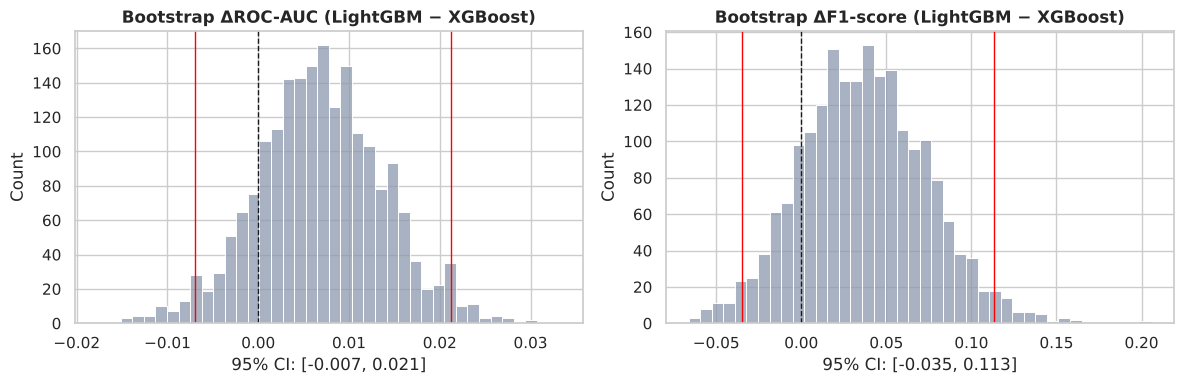

In [26]:
rng = np.random.default_rng(RANDOM_STATE)
p_lgb = final_models["LightGBM (tuned)"].predict_proba(X_test)[:, 1]
p_xgb = final_models["XGBoost (tuned)"].predict_proba(X_test)[:, 1]
y_arr = y_test.to_numpy()

d_auc, d_f1 = [], []
for _ in range(2000):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    if len(np.unique(y_arr[idx])) < 2:
        continue
    d_auc.append(roc_auc_score(y_arr[idx], p_lgb[idx]) - roc_auc_score(y_arr[idx], p_xgb[idx]))
    d_f1.append(f1_score(y_arr[idx], p_lgb[idx] >= thresholds["LightGBM"]) - f1_score(y_arr[idx], p_xgb[idx] >= thresholds["XGBoost"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, d, name in zip(axes, [d_auc, d_f1], ["ROC-AUC", "F1-score"]):
    lo, hi = np.percentile(d, [2.5, 97.5])
    sns.histplot(d, bins=40, color="#8d99ae", ax=ax)
    ax.axvline(0, color="k", ls="--", lw=1); ax.axvline(lo, color="red", lw=1); ax.axvline(hi, color="red", lw=1)
    ax.set(title=f"Bootstrap Δ{name} (LightGBM − XGBoost)", xlabel=f"95% CI: [{lo:.3f}, {hi:.3f}]")
    print(f"Δ{name}: mean = {np.mean(d):+.4f}, 95% CI = [{lo:+.4f}, {hi:+.4f}] -> "
          f"{'contains 0: no significant difference' if lo <= 0 <= hi else 'excludes 0: significant difference'}")
plt.tight_layout(); plt.show()

### 4.4 Feature importance (permutation importance on the test set)

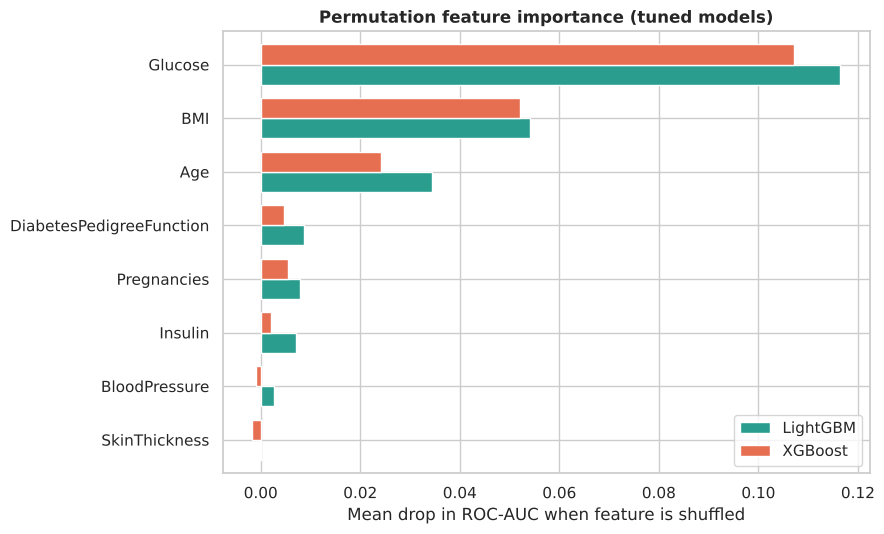

In [27]:
# Permutation importance: drop in ROC-AUC when one feature's values are shuffled.
# Model-agnostic, so the two algorithms are compared on identical terms.
imp = {}
for algo in ["LightGBM", "XGBoost"]:
    r = permutation_importance(final_models[f"{algo} (tuned)"], X_test, y_test, scoring="roc_auc",
                               n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1)
    imp[algo] = pd.Series(r.importances_mean, index=X.columns)
imp = pd.DataFrame(imp).sort_values("LightGBM")

ax = imp.plot.barh(figsize=(9, 5.5), color=[COLORS["LightGBM"], COLORS["XGBoost"]], width=0.75)
ax.set(title="Permutation feature importance (tuned models)", xlabel="Mean drop in ROC-AUC when feature is shuffled", ylabel="")
plt.tight_layout(); plt.show()

Both algorithms rely on essentially the same features: **Glucose dominates**, followed by BMI and Age. This matches the EDA, and the models agree on what drives diabetes risk.

### 4.5 Efficiency: training and prediction time

In [28]:
# Time the FINAL tuned configurations (average of 10 runs) so the comparison is not distorted by their different tree counts
timing = {}
for algo in ["LightGBM", "XGBoost"]:
    pipe = final_models[f"{algo} (tuned)"]
    fit_t, pred_t = [], []
    for _ in range(10):
        t0 = time.perf_counter(); pipe.fit(X_train, y_train); fit_t.append(time.perf_counter() - t0)
        t0 = time.perf_counter(); pipe.predict(X_test); pred_t.append(time.perf_counter() - t0)
    timing[algo] = {"Train time (s)": np.mean(fit_t), "Predict time (s)": np.mean(pred_t),
                    "Random-search time (s)": tuning_time[algo]}
timing = pd.DataFrame(timing).T
timing.round(4)

,Train time (s),Predict time (s),Random-search time (s)
LightGBM,0.0185,0.0023,7.6929
XGBoost,0.0208,0.0019,7.3460


### 4.6 Consolidated comparison

In [29]:
summary = test_results.loc[["LightGBM (baseline)", "XGBoost (baseline)", "LightGBM (tuned)", "XGBoost (tuned)",
                           "LightGBM (tuned + threshold)", "XGBoost (tuned + threshold)"]].copy()
summary.loc["LightGBM (tuned)", "CV ROC-AUC"] = searches["LightGBM"].best_score_
summary.loc["XGBoost (tuned)", "CV ROC-AUC"] = searches["XGBoost"].best_score_
summary.loc["LightGBM (baseline)", "CV ROC-AUC"] = baseline_cv["LightGBM"]["roc_auc"][0]
summary.loc["XGBoost (baseline)", "CV ROC-AUC"] = baseline_cv["XGBoost"]["roc_auc"][0]
for algo in ["LightGBM", "XGBoost"]:
    summary.loc[f"{algo} (tuned + threshold)", "CV ROC-AUC"] = searches[algo].best_score_
summary = summary.rename(columns=dict(zip(metrics, labels))).round(3)
summary.style.highlight_max(axis=0, color="#cdeac0", props="font-weight:bold;")\
       .set_caption("Test-set metrics (CV ROC-AUC = 5-fold cross-validated, training set); best value per column highlighted")

,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV ROC-AUC
LightGBM (baseline),0.760000,0.667000,0.630000,0.648000,0.817000,0.798000
XGBoost (baseline),0.766000,0.696000,0.593000,0.640000,0.806000,0.782000
LightGBM (tuned),0.747000,0.703000,0.481000,0.571000,0.827000,0.841000
XGBoost (tuned),0.753000,0.674000,0.574000,0.620000,0.820000,0.843000
LightGBM (tuned + threshold),0.734000,0.582000,0.852000,0.692000,0.827000,0.841000
XGBoost (tuned + threshold),0.747000,0.627000,0.685000,0.655000,0.820000,0.843000


## 5. Report: Comparative Analysis and Practical Implications

### Setup
Pima diabetes data (768 patients, 8 predictors, 34.9% positive). Hidden missing values (zeros in Insulin, SkinThickness, BloodPressure, BMI, Glucose) were converted to `NaN` and median-imputed inside a pipeline fitted on training data only. A stratified 80/20 split was used. LightGBM and XGBoost were each tuned with the same budget (60 random-search configurations, 5-fold stratified CV, ROC-AUC objective). The decision threshold was then chosen from out-of-fold training predictions.

### Results (held-out test set, n = 154)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| LightGBM, baseline | 0.760 | 0.667 | 0.630 | 0.648 | 0.817 |
| XGBoost, baseline | 0.766 | 0.696 | 0.593 | 0.640 | 0.806 |
| LightGBM, tuned (threshold 0.5) | 0.747 | 0.703 | 0.481 | 0.571 | 0.827 |
| XGBoost, tuned (threshold 0.5) | 0.753 | 0.674 | 0.574 | 0.620 | 0.820 |
| LightGBM, tuned + threshold (0.29) | 0.734 | 0.582 | 0.852 | 0.692 | 0.827 |
| XGBoost, tuned + threshold (0.41) | 0.747 | 0.627 | 0.685 | 0.655 | 0.820 |

### Key findings
1. **The two algorithms perform almost identically.** Tuned ROC-AUC is 0.827 (LightGBM) vs 0.820 (XGBoost) on the test set and 0.841 vs 0.843 in cross-validation. The bootstrap 95% intervals for the AUC and F1 differences both include zero, so **neither model is significantly better** on this data.
2. **Tuning improved ranking quality, not the default-threshold metrics.** ROC-AUC rose by about 0.01 for both models, but accuracy, recall and F1 at the 0.5 cut-off fell slightly, most visibly for LightGBM (recall 0.63 → 0.48). The tuned models are more conservative, which suggests the 0.5 cut-off should not be taken for granted.
3. **Threshold tuning matters more than hyperparameter tuning here.** Choosing the cut-off from out-of-fold predictions raised recall to 0.85 (LightGBM) and 0.69 (XGBoost) and gave the best F1 values (0.69 and 0.66), at the cost of precision and a little accuracy. This is the right trade-off for a screening use case, where a missed diabetic patient is costlier than a false alarm.
4. **Both models learn the same signal.** Glucose dominates, followed by BMI and Age, which matches the EDA. SkinThickness and BloodPressure contribute almost nothing.
5. **Efficiency is a tie at this scale.** Training takes about 0.02 s for each and the random searches took about 8 s each. LightGBM's speed advantage only appears on much larger datasets.

### Strengths and weaknesses
| | LightGBM | XGBoost |
|---|---|---|
| Strengths | Slightly higher test ROC-AUC; reached the highest recall and F1 once the threshold was tuned; very fast and memory-light on large data | More stable results (smaller CV standard deviation); better recall and F1 at the default 0.5 cut-off after tuning; shallow depth-2 trees with strong regularisation suited the small sample |
| Weaknesses | Leaf-wise growth can overfit small datasets (it needed small `num_leaves` and `min_child_samples`); at the default 0.5 cut-off its tuned version missed the most diabetic patients (recall 0.48), so the threshold needs adjusting | Marginally lower ROC-AUC on the test set; no speed benefit visible here, and typically slower than LightGBM on large data |

### Practical implications
- **Algorithm choice is secondary on small tabular data.** Either library gives about 0.82-0.84 ROC-AUC, so choose on operational grounds: LightGBM for large or frequently retrained workloads, XGBoost for its stability and maturity.
- **Choose the operating point deliberately.** Set the decision threshold according to the cost of missed cases vs false alarms, and use out-of-fold data (not the test set) to choose it.
- **Data quality is the main lever.** Insulin is ~49% missing and SkinThickness ~30%. Collecting these measurements properly is likely to help more than further model tuning.
- **Use the output as a screening aid.** Models like these support triage and follow-up testing; they are not a diagnosis.

### Limitations
The test set is small (154 patients, 54 positive), so metrics move by several points with a different split, as the wide bootstrap intervals show. Results come from one split and one tuning run; repeated nested cross-validation would give a firmer comparison. The data come from a single population (Pima Indian women aged 21+), so the findings may not transfer elsewhere.